In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY)
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


In [3]:
read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/ohca_data/ohca_2010_2018.csv")
ohca_count_2010_2018 = pd.read_csv(read_from_filepath)

read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/ohca_data/ohca_2019_2021.csv")
ohca_count_2019_2021 = pd.read_csv(read_from_filepath)

In [8]:
ohca_combined = pd.concat([ohca_count_2010_2018, ohca_count_2019_2021], ignore_index=True)
ohca_combined = ohca_combined.drop(columns=['Unnamed: 0'])
ohca_combined

,pln_area_n,subzone_n,year,month,incident_count
0,ang mo kio,ang mo kio town centre,2010,5,1
1,ang mo kio,ang mo kio town centre,2010,7,2
2,ang mo kio,ang mo kio town centre,2010,9,1
3,ang mo kio,ang mo kio town centre,2011,5,1
4,ang mo kio,ang mo kio town centre,2011,9,1
...,...,...,...,...,...
15117,yishun,yishun west,2021,8,1
15118,yishun,yishun west,2021,9,2
15119,yishun,yishun west,2021,10,5
15120,yishun,yishun west,2021,11,7


#### Plotting subzone count vs incident count

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_20040/2758657431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=ohca_combined, x='incident_count', palette='viridis')


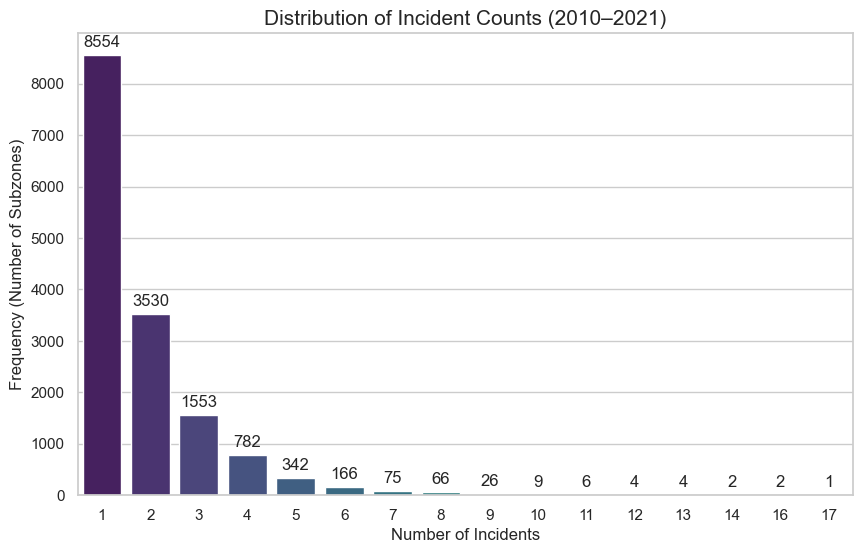

In [5]:
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Create the count plot
# 'ohca_combined' is the DataFrame from our previous step
ax = sns.countplot(data=ohca_combined, x='incident_count', palette='viridis')

# Add labels and title
plt.title('Distribution of Incident Counts (2010–2021)', fontsize=15)
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Frequency (Number of Subzones)', fontsize=12)

# add the actual count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

Most subzones have 1 - 5 OHCA cases in a month 

In [9]:
### filter for subzones with >=10 OHCA cases in a month
high_incident_df = ohca_combined[ohca_combined['incident_count'] >= 10]

high_incident_df_sorted = high_incident_df.sort_values(by='incident_count', ascending=False)

display(high_incident_df_sorted)

,pln_area_n,subzone_n,year,month,incident_count
14388,tampines,tampines east,2020,7,17
14381,tampines,tampines east,2019,12,16
10774,bedok,bedok north,2021,12,16
14393,tampines,tampines east,2020,12,14
14383,tampines,tampines east,2020,2,14
10773,bedok,bedok north,2021,11,13
14442,tampines,tampines west,2021,7,13
8811,tampines,tampines east,2018,2,13
8793,tampines,tampines east,2016,8,13
10755,bedok,bedok north,2020,5,12


Number of OHCA cases increases in the later years (2019 - 2021) for subzones like tampines, bedok and aljunied. 

#### Plotting subzone count vs incident count by year

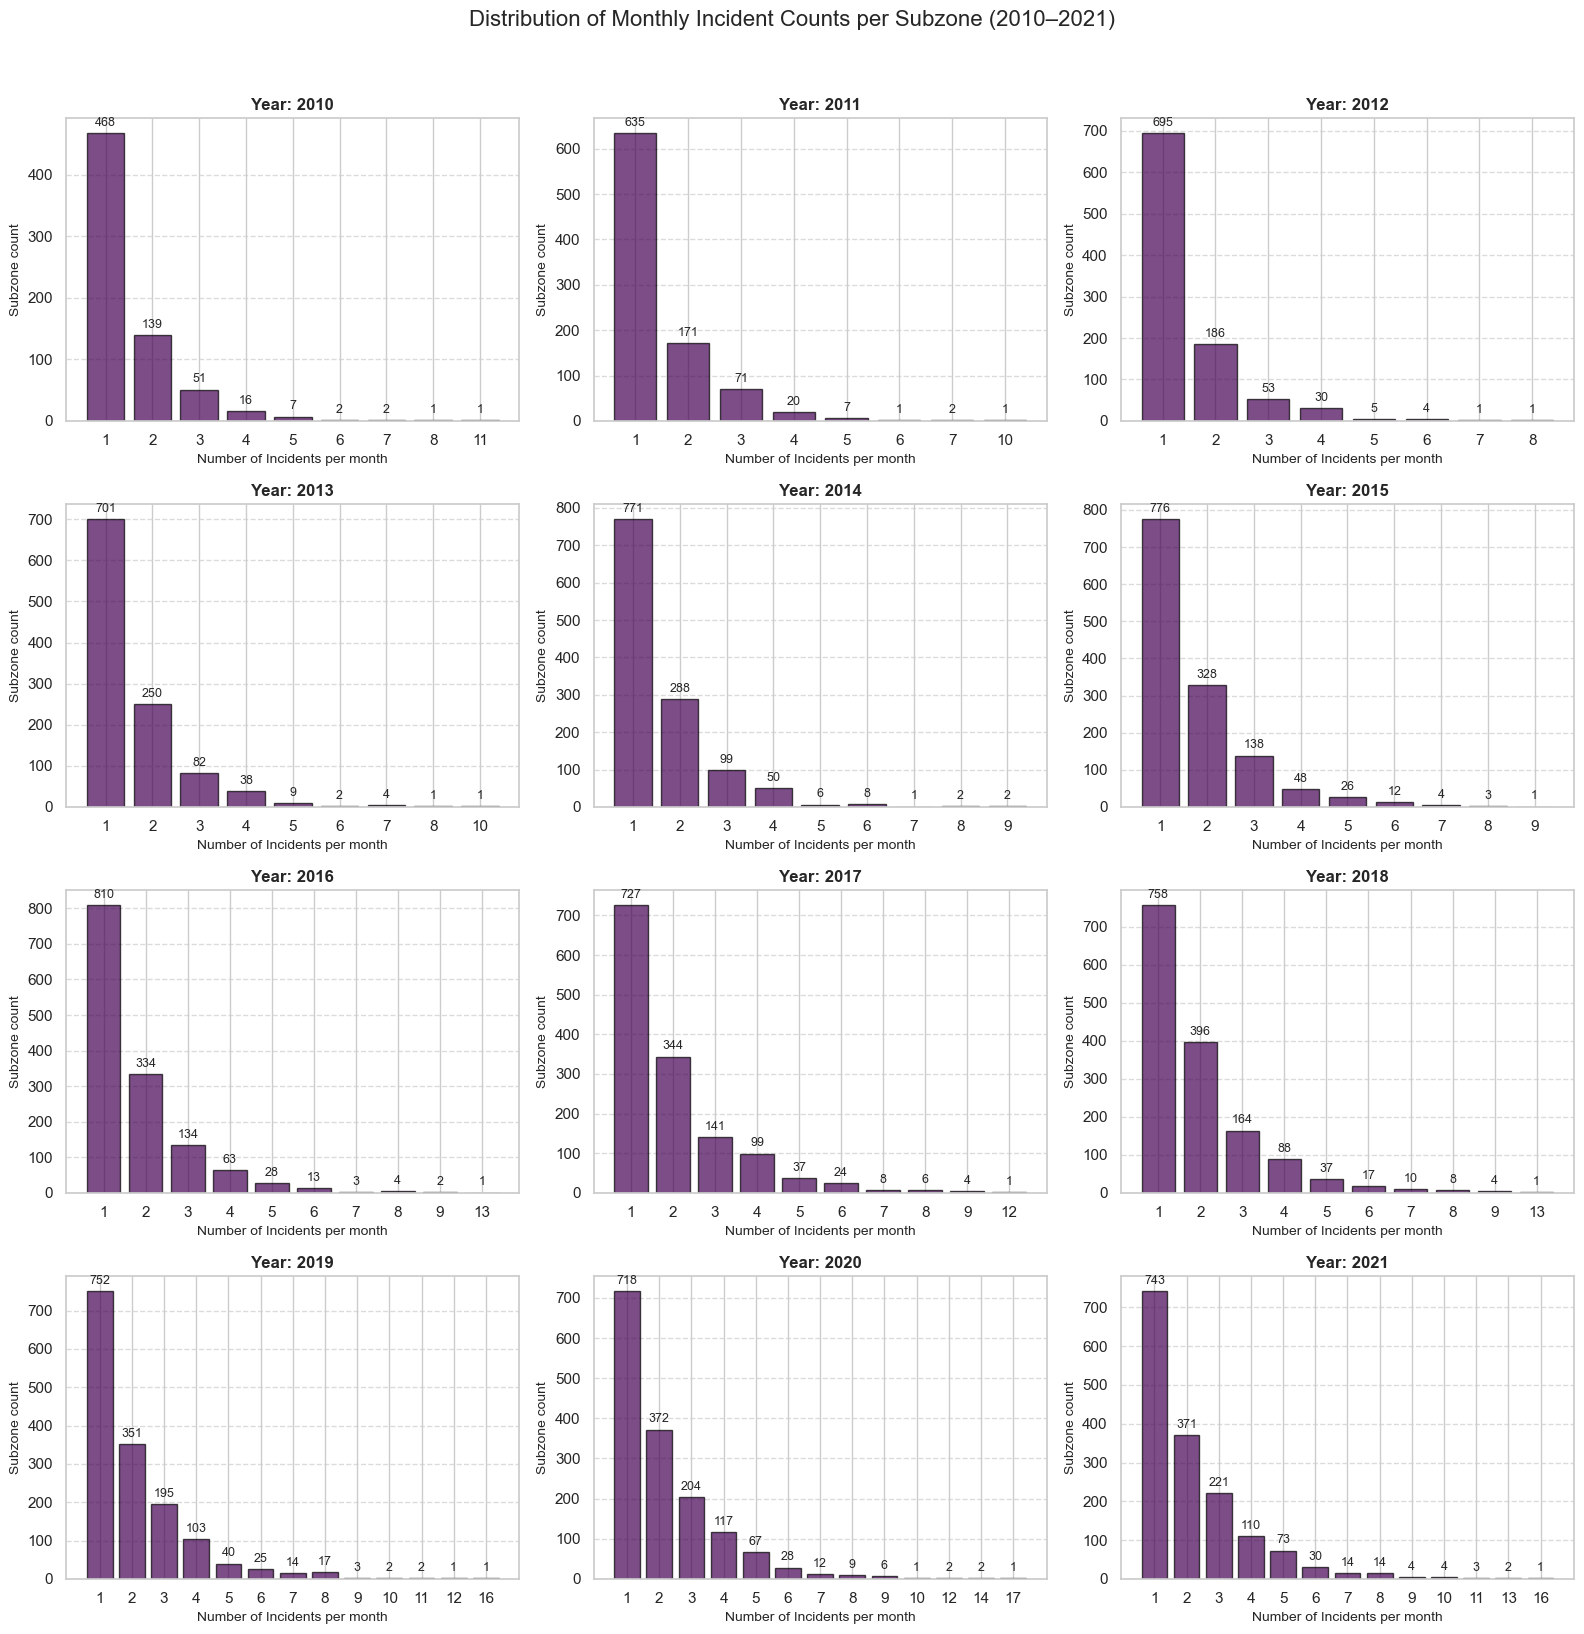

In [19]:
years = sorted(ohca_combined['year'].unique())
n_years = len(years)
cols = 3
rows = math.ceil(n_years / cols)

# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# iterate through each year and plot
for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter data for the specific year
    year_data = ohca_combined[ohca_combined['year'] == year]
    
    # Count frequencies of each incident_count value
    # value_counts() calculates what sns.countplot does automatically
    counts = year_data['incident_count'].value_counts().sort_index()
    
    # Create the bar chart
    # We use counts.index.astype(str) to treat the counts as categories
    bars = ax.bar(counts.index.astype(str), counts.values, color='#440154', edgecolor='black', alpha=0.7)
    
    # Add titles and labels
    ax.set_title(f"Year: {year}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Number of Incidents per month", fontsize=10)
    ax.set_ylabel("Subzone count", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 4. Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# clean up unused subplots 
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Final adjustments
plt.suptitle('Distribution of Monthly Incident Counts per Subzone (2010–2021)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Proportion of subzones with OHCA cases in a month

In [14]:
read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/ohca_data/ohca_binary_complete.csv")
ohca_binary = pd.read_csv(read_from_filepath)
ohca_binary = ohca_binary.drop(columns=['Unnamed: 0'])

In [15]:
ohca_binary.head()

,pln_area_n,subzone_n,year,month,ohca_binary,above_60_proportion,male_chinese_proportion,female_chinese_proportion,male_malays_proportion,female_malays_proportion,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,school_encoding,airport,is_residential
0,ang mo kio,ang mo kio town centre,2010,4,0,138.561604,417.390841,435.464093,23.77779,27.989551,27.616357,30.175401,14.501253,16.580477,0,0,0,0,0,1
1,ang mo kio,ang mo kio town centre,2010,5,1,138.561604,417.390841,435.464093,23.77779,27.989551,27.616357,30.175401,14.501253,16.580477,0,0,0,0,0,1
2,ang mo kio,ang mo kio town centre,2010,6,0,138.561604,417.390841,435.464093,23.77779,27.989551,27.616357,30.175401,14.501253,16.580477,0,0,0,0,0,1
3,ang mo kio,ang mo kio town centre,2010,7,1,138.561604,417.390841,435.464093,23.77779,27.989551,27.616357,30.175401,14.501253,16.580477,0,0,0,0,0,1
4,ang mo kio,ang mo kio town centre,2010,8,0,138.561604,417.390841,435.464093,23.77779,27.989551,27.616357,30.175401,14.501253,16.580477,0,0,0,0,0,1


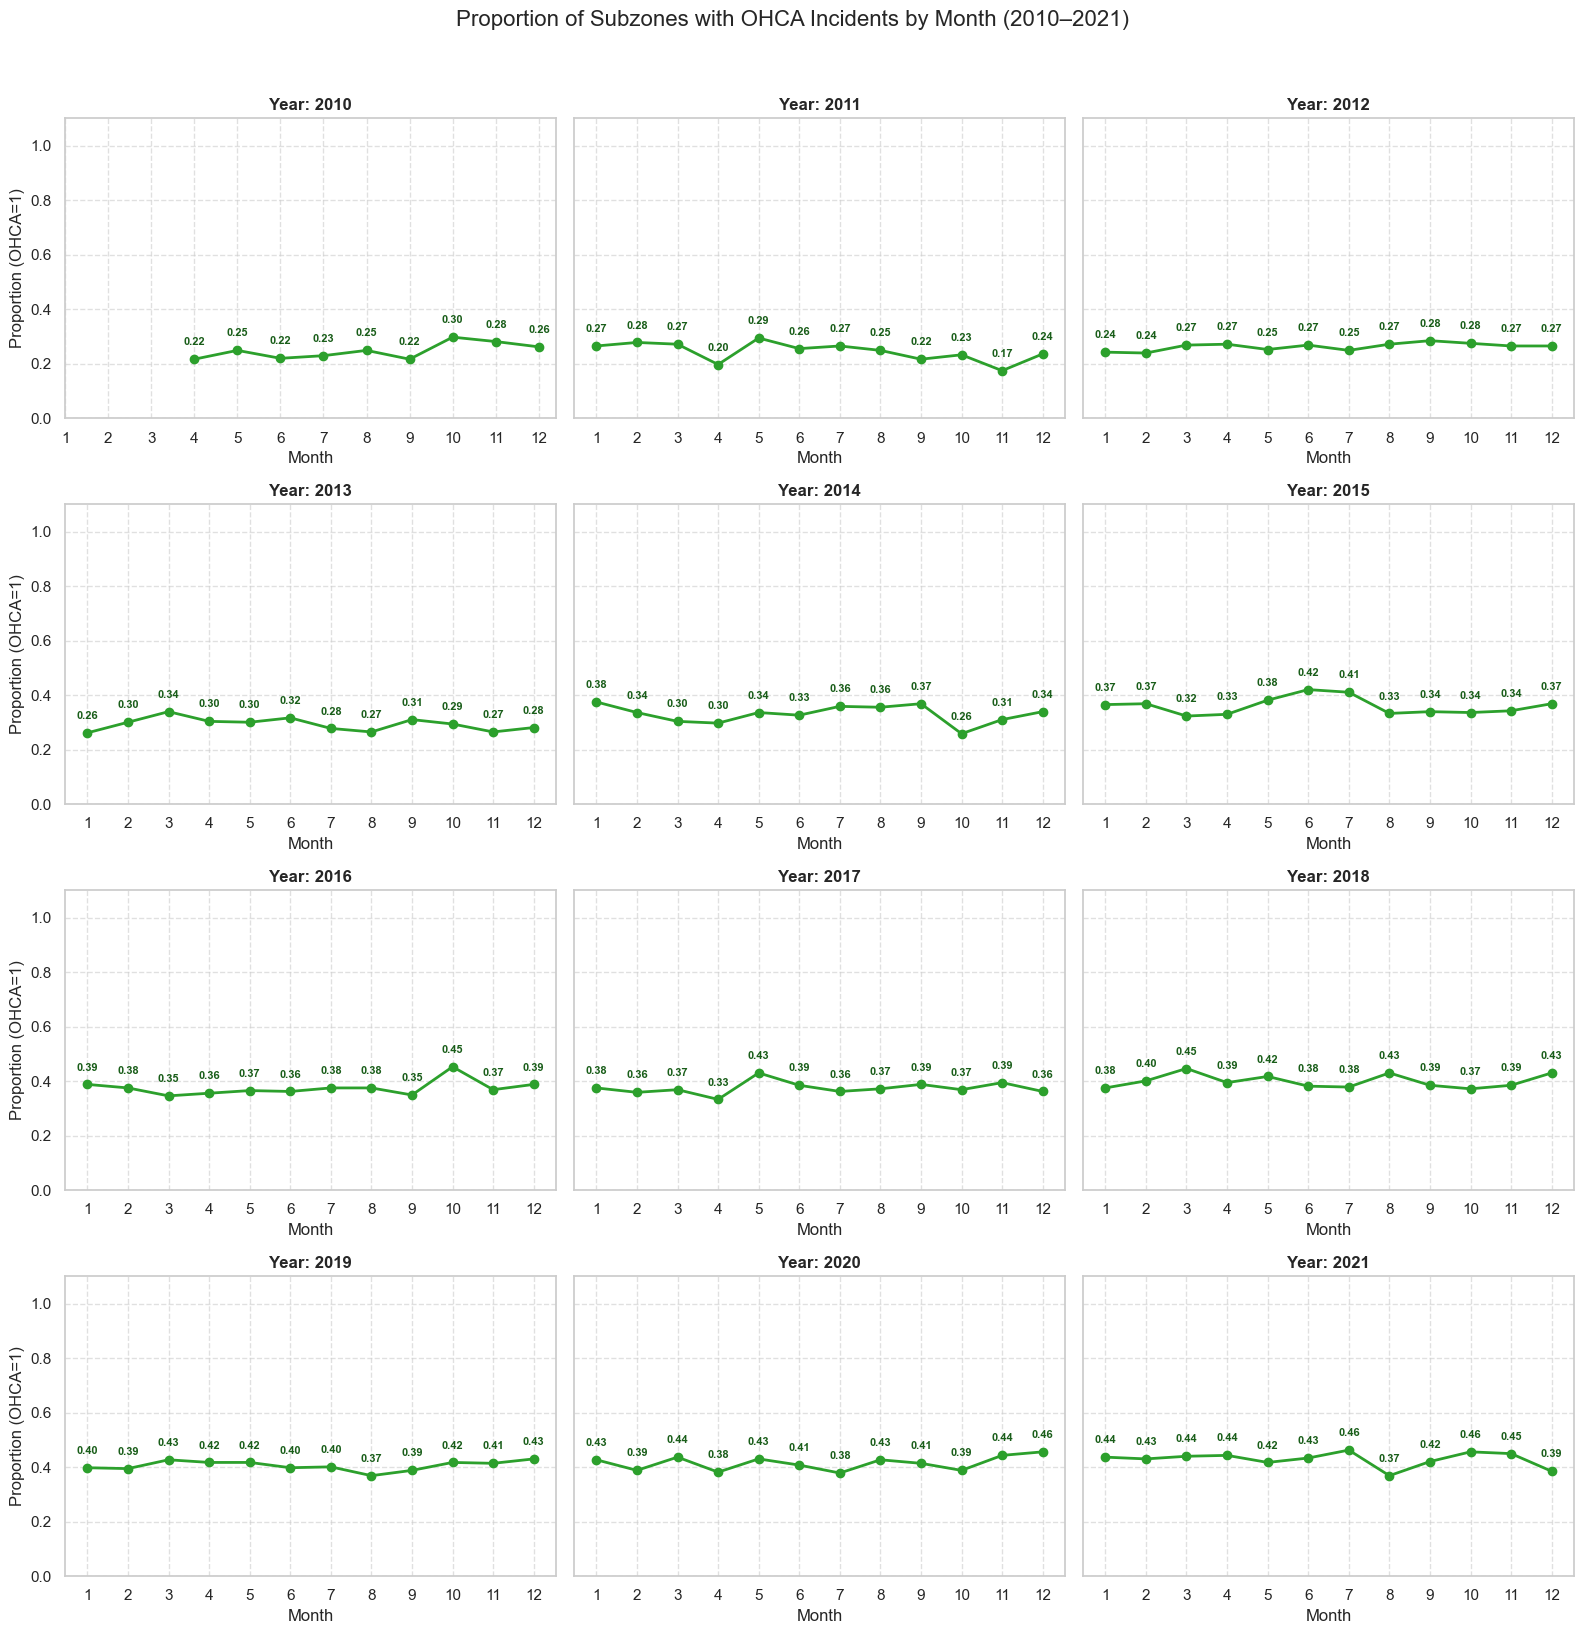

In [30]:
# grouping by year and month to find the average of ohca_binary
# by finding the mean, we calculate (sum of ohca binary) / (count of subzones). 
# this give the proportion of subzones with >=1 incident that month
monthly_proportions = ohca_binary.groupby(['year', 'month'])['ohca_binary'].mean().reset_index()

# setup the grid layout
years = sorted(monthly_proportions['year'].unique())
n_years = len(years)
cols = 3
rows = math.ceil(n_years / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), sharey=True)
axes = axes.flatten()

# iterate and plot
for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter for the specific year
    year_data = monthly_proportions[monthly_proportions['year'] == year]
    
    # Plotting Month vs Proportion
    ax.plot(year_data['month'], year_data['ohca_binary'], marker='o', color='#2ca02c', linewidth=2)

    for x, y in zip(year_data['month'], year_data['ohca_binary']):
            ax.annotate(f'{y:.2f}',               # The text (formatted to 2 decimal places)
                        (x, y),                   # The point to label
                        textcoords="offset points", # How to position the text
                        xytext=(0, 10),           # Distance from text to point (x,y) in points
                        ha='center',              # Horizontal alignment
                        fontsize=8,               # Font size
                        fontweight='bold',
                        color='#1a5e1a')
    
    # Formatting
    ax.set_title(f"Year: {year}", fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))  # Ensure all 12 months are visible
    ax.set_xlabel("Month")
    if i % cols == 0:
        ax.set_ylabel("Proportion (OHCA=1)")
    
    ax.set_ylim(0, 1.1)  # Proportion is between 0 and 1
    ax.grid(True, linestyle='--', alpha=0.6)

# cleanup unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Proportion of Subzones with OHCA Incidents by Month (2010–2021)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Plotting for Geospatial data

In [20]:
read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/combined_demographic_geo_2010_2018.csv")
interpolated_demographic_2010_2018 = pd.read_csv(read_from_filepath)

read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/combined_demographic_geo_2019_2021.csv")
interpolated_demographic_2019_2021 = pd.read_csv(read_from_filepath)

combined_demographic = pd.concat([interpolated_demographic_2010_2018,
                                  interpolated_demographic_2019_2021], ignore_index=True)
combined_demographic = combined_demographic.drop(columns = ["Unnamed: 0"])
combined_demographic.head()

,subzone_n,pln_area_n,Year,total,above_60,above_60_proportion,male_chinese_proportion,female_chinese_proportion,male_malays_proportion,female_malays_proportion,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,school_encoding,airport,is_residential
0,admiralty,sembawang,2010,11412,974,85.348756,357.167893,362.337890,74.044865,74.483000,46.442341,44.602173,20.855240,18.226428,0,0,0,1,0,1
1,admiralty,sembawang,2011,11744,1071,91.195504,354.138283,359.587875,76.549728,77.826975,46.151226,44.618529,20.265668,18.136921,0,0,0,1,0,1
2,admiralty,sembawang,2012,12104,1154,95.340383,351.536682,357.319894,78.734303,80.717118,45.769993,44.778586,19.745539,18.175810,0,0,0,1,0,1
3,admiralty,sembawang,2013,12438,1238,99.533687,349.734684,355.603795,81.041968,83.695128,45.505708,44.782119,19.376105,18.330921,0,0,0,1,0,1
4,admiralty,sembawang,2014,12777,1326,103.780230,347.655944,353.760664,83.274634,86.561791,45.237536,44.767942,18.783752,18.470690,0,0,0,1,0,1


In [22]:
years_to_keep = [2014, 2019]

geospatial_filtered = combined_demographic[combined_demographic['Year'].isin(years_to_keep)]
geospatial_filtered.head()

,subzone_n,pln_area_n,Year,total,above_60,above_60_proportion,male_chinese_proportion,female_chinese_proportion,male_malays_proportion,female_malays_proportion,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,school_encoding,airport,is_residential
4,admiralty,sembawang,2014,12777,1326,103.780230,347.655944,353.760664,83.274634,86.561791,45.237536,44.767942,18.783752,18.470690,0,0,0,1,0,1
13,airport road,paya lebar,2014,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0,0,0
22,alexandra hill,bukit merah,2014,17648,4298,243.540345,356.357661,366.160471,78.082502,76.155938,53.547144,52.357208,8.102901,12.126020,1,0,0,1,0,0
31,alexandra north,bukit merah,2014,3103,263,84.756687,338.382211,405.091847,0.000000,10.957138,58.975185,78.955849,50.273928,50.273928,0,0,0,1,0,1
40,aljunied,geylang,2014,16405,3313,201.950625,407.071015,411.642792,39.195367,39.561109,32.977751,29.868942,17.189881,18.774764,1,0,0,1,0,1


In [25]:
### drop any potential duplicates
# keep='first' ensures we keep the first occurrence and drop subsequent duplicates
geospatial_unique = geospatial_filtered.drop_duplicates(subset=['subzone_n', 'pln_area_n', 'Year'], keep='first')

print(f"Original row count: {len(geospatial_filtered)}")
print(f"Unique row count: {len(geospatial_unique)}")

Original row count: 712
Unique row count: 712


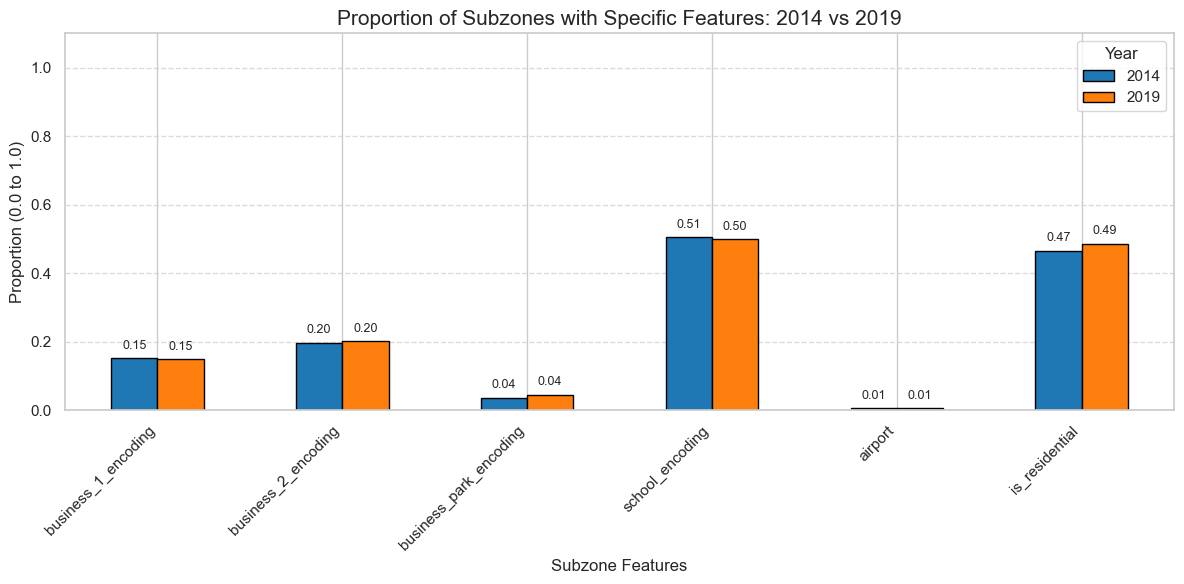

In [ ]:
feature_cols = [
    'business_1_encoding', 'business_2_encoding', 
    'business_park_encoding', 'school_encoding', 
    'airport', 'is_residential'
]

# by finding the mean, we calculate (sum of ohca binary) / (count of subzones). 
# this give the proportion of subzones with >=1 incident that month
proportions = geospatial_unique.groupby('Year')[feature_cols].mean()

# plotting
# We transpose (.T) so that features are on the X-axis and years are in the legend
ax = proportions.T.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'], edgecolor='black')

# Formatting the graph
plt.title('Proportion of Subzones with Specific Features: 2014 vs 2019', fontsize=15)
plt.ylabel('Proportion (0.0 to 1.0)', fontsize=12)
plt.xlabel('Subzone Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # Proportions stay between 0 and 1
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

The geospatial data of interest did not change much between 2014 and 2019 masterplans